# 05 · Visualizations for Paper
### Regenerate every publication figure from saved artifacts

**Author:** Ibrahim Denis Fofanah — Pace University | RiseAfrica Foundation for STEM and Innovation
**Project:** Machine Learning Approaches to Crop Yield Prediction and Post-Harvest Loss Reduction — Evidence from Sierra Leone

---

In [1]:
# ── Setup & project-root anchoring ────────────────────────────────────────────
import sys, os, warnings

# Resolve paths whether launched from repo root or from notebooks/
if not os.path.exists('data/raw') and os.path.exists('../data/raw'):
    os.chdir('..')
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 50)

for d in ['data/processed', 'outputs/figures', 'outputs/models', 'outputs/reports']:
    os.makedirs(d, exist_ok=True)

print(f'Working directory: {os.getcwd()}')

Working directory: /Users/ibrahimfofanah/sierraleone-agri-ml


## 1. Load Artifacts

In [2]:
from src import feature_engineering as fe
from src import models as mdl
from src import evaluation as ev
from src import visualization as viz
from sklearn.model_selection import train_test_split

analysis    = pd.read_csv('data/processed/analysis_dataset.csv')
ml_df       = pd.read_csv('data/processed/processed_dataset.csv')
results_df  = pd.read_csv('outputs/reports/model_performance.csv')
print('Artifacts loaded.')

Artifacts loaded.


## 2. Figures 1 & 2 — Yield Trends (EDA)

[✓] Figure saved: fig1_rice_yield_trend


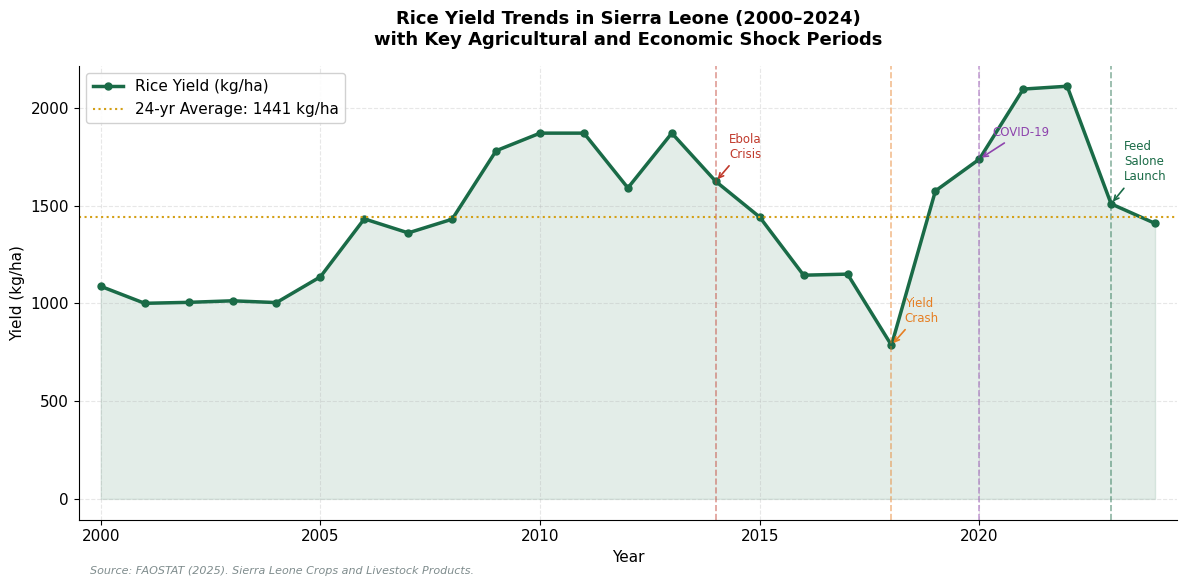

[✓] Figure saved: fig2_multi_crop_yields


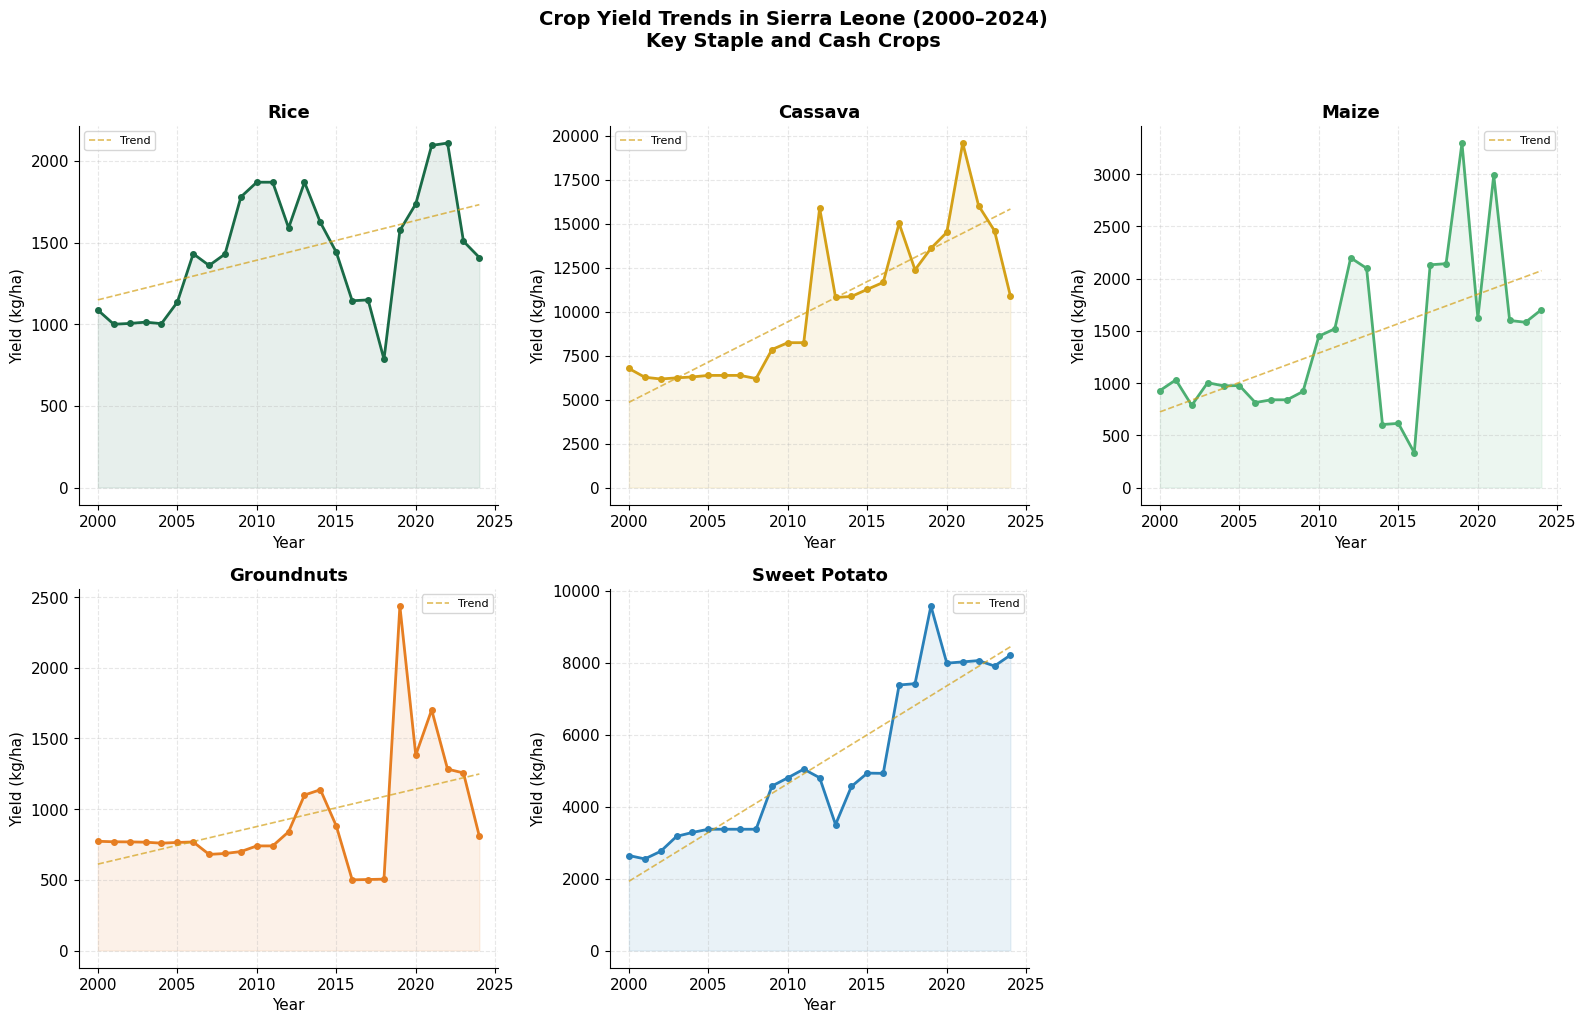

In [3]:
viz.plot_rice_yield_trend(analysis); plt.show()
viz.plot_multi_crop_yield(analysis); plt.show()

## 3. Figure 3 — Model Performance Comparison

[✓] Figure saved: fig3_model_comparison


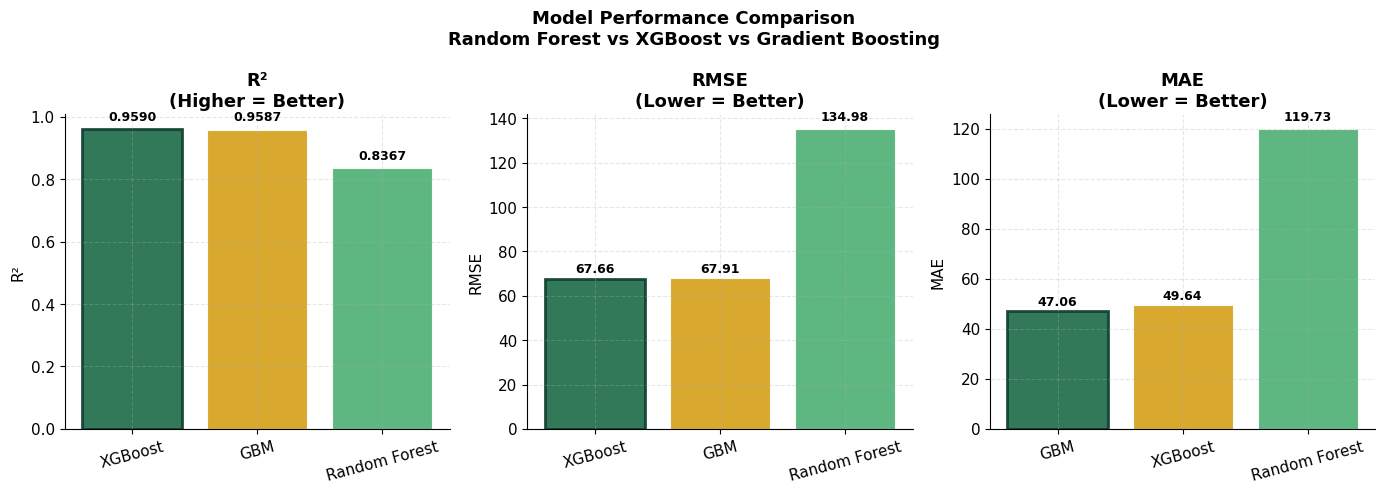

In [4]:
viz.plot_model_comparison(results_df); plt.show()

## 4. Figure 4 — Actual vs Predicted

[✓] Features: 151 | Samples: 25
    Target: Rice_Yield | Range: 785.6 – 2109.8
[✓] Model loaded: outputs/models/XGBoost.pkl
[✓] Model loaded: outputs/models/GBM.pkl
[✓] Model loaded: outputs/models/Random_Forest.pkl


[✓] Figure saved: fig5_actual_vs_predicted


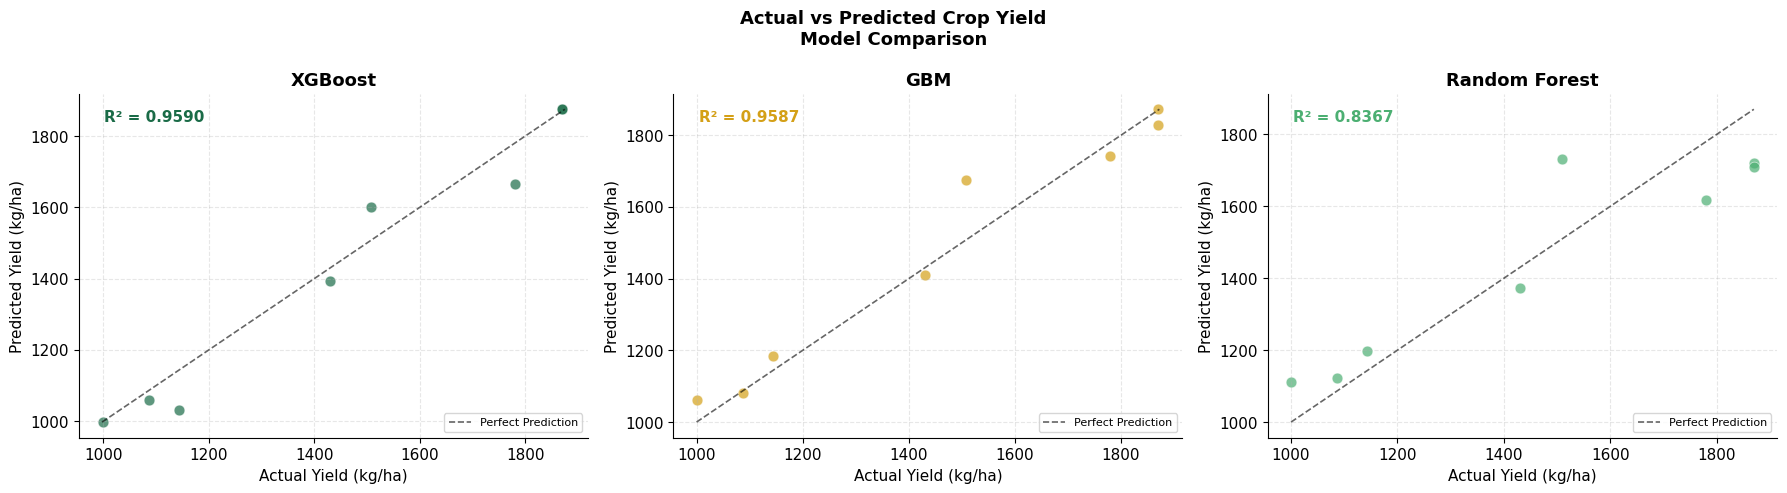

In [5]:
X, y, feature_names = fe.prepare_features(ml_df, target_col='Rice_Yield')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

trained = {name: mdl.load_model(f"outputs/models/{name.replace(' ', '_')}.pkl")
           for name in results_df['Model']}
predictions = {name: m.predict(X_test) for name, m in trained.items()}

viz.plot_actual_vs_predicted(y_test, predictions); plt.show()

## 5. Figure 5 — Feature Importance (Best Model)

[✓] Figure saved: fig4_feature_importance_xgboost


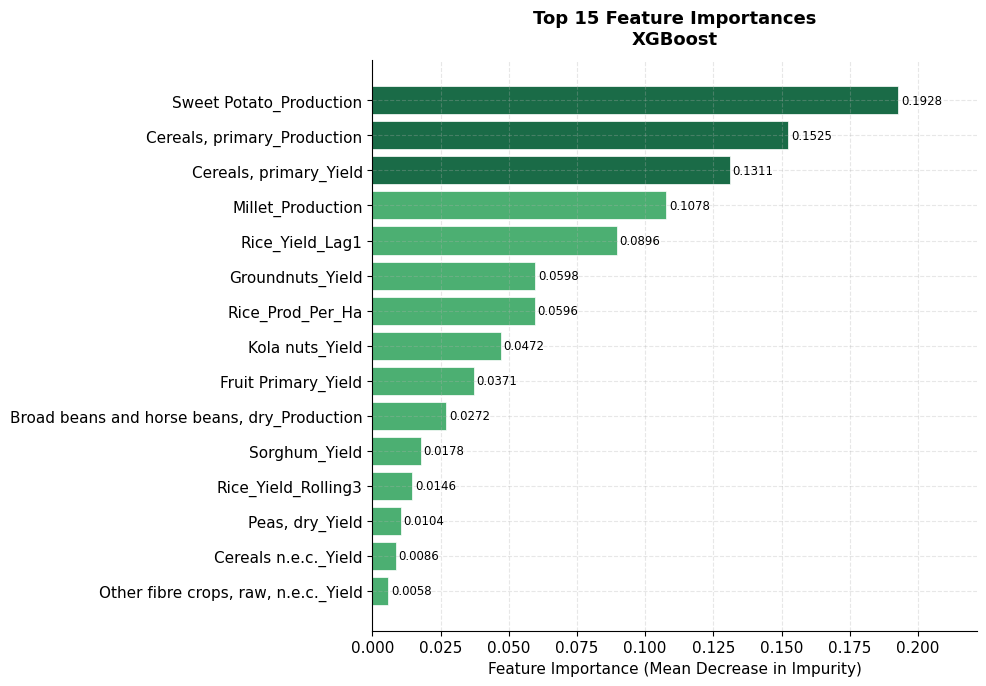

In [6]:
best_name = results_df.iloc[0]['Model']
fi_df = ev.get_feature_importance(trained[best_name], feature_names, best_name)
viz.plot_feature_importance(fi_df, top_n=15, model_name=best_name); plt.show()

## 6. Figure 6 — Production Overview

[✓] Figure saved: fig6_production_overview


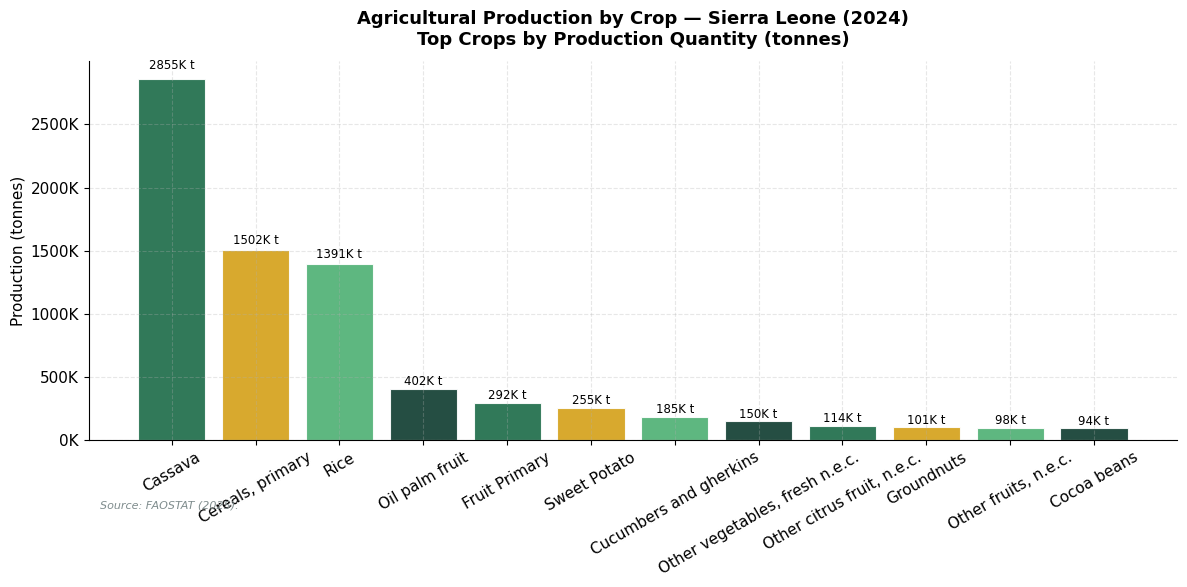


All paper figures regenerated in outputs/figures/


In [7]:
viz.plot_production_overview(analysis); plt.show()
print('\nAll paper figures regenerated in outputs/figures/')